In [5]:
# Load the cleaned master dataset

import pandas as pd

# Path to the cleaned master table CSV
file_path = "/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv"

# Load the dataset
df = pd.read_csv(file_path)

# Preview the data
print("Shape of dataset:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nBasic info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (32593, 15)

First few rows:


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,num_assessments,total_clicks
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0



Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_student            32593 non-null  int64  
 1   code_module           32593 non-null  object 
 2   code_presentation     32593 non-null  object 
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              32593 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  avg_score             25820 non-null  float64
 13  num_assessments       25820 non-null  float64
 14  total_clicks          29228 non-null  float64
dtypes: flo

In [6]:
# Create binary target variable: 1 = Pass/Distinction, 0 = Fail/Withdrawn
df["target"] = df["final_result"].map({
    "Pass": 1,
    "Distinction": 1,
    "Fail": 0,
    "Withdrawn": 0
})

In [7]:
# Count distinct (unique) values per column
unique_counts = df.nunique().sort_values(ascending=False)

# Display nicely
print("Number of unique values per column:\n")
print(unique_counts)

Number of unique values per column:

id_student              28785
total_clicks             5380
avg_score                2668
studied_credits            61
num_assessments            14
region                     13
imd_band                   11
code_module                 7
num_of_prev_attempts        7
highest_education           5
code_presentation           4
final_result                4
age_band                    3
gender                      2
disability                  2
target                      2
dtype: int64


In [8]:
def final_result_breakdown(df, group_col):
    """
    Creates a summary table showing counts and % breakdown of final_result
    for each category in the specified column.
    """
    result_counts = (
        df.groupby(group_col, observed=True)['final_result']
        .value_counts(normalize=False)
        .unstack(fill_value=0)
    )

    result_percent = (
        df.groupby(group_col, observed=True)['final_result']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    ).round(1)

    combined = result_counts.astype(int).copy()
    for col in result_percent.columns:
        combined[f"% {col}"] = result_percent[col]

    combined["Num Students"] = combined[result_counts.columns].sum(axis=1)
    combined = combined.sort_values("Num Students", ascending=False)

    return combined.reset_index()

In [9]:
region_table = final_result_breakdown(df, "region")

# Save breakdown of final result percentages by region
region_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_region.csv", index=False)

In [10]:
imd_table = final_result_breakdown(df, "imd_band")

# Save breakdown of final result percentages by socioeconomic band (IMD)
imd_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_imd_band.csv", index=False)

In [11]:
age_band_table = final_result_breakdown(df, "age_band")

# Save breakdown of final results by age groups — helps understand how outcomes vary with student age
age_band_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_age_band.csv", index=False)

In [12]:
gender_table = final_result_breakdown(df, "gender")

# Save final result breakdown by gender — to check for any performance gaps between males and females
gender_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_gender.csv", index=False)

In [13]:
disability_table = final_result_breakdown(df, "disability")

# Save final result breakdown by disability status — important for understanding accessibility and support gaps
disability_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_disability.csv", index=False)

In [14]:
code_presentation_table = final_result_breakdown(df, "code_presentation")

# Save final result breakdown by course presentation (term/cohort) — to detect cohort or term effects
code_presentation_table.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_code_presentation.csv", index=False)

In [15]:
def binned_final_result_breakdown(df, numeric_col, bins, labels, save_path):
    """
    Bins a numeric column, then creates and saves a final_result breakdown table by those bins.
    """
    df = df.copy()
    df[numeric_col + "_binned"] = pd.cut(df[numeric_col], bins=bins, labels=labels, include_lowest=True)

    # Drop rows where binning was not possible (e.g., NaN clicks)
    df_binned = df.dropna(subset=[numeric_col + "_binned"])

    table = final_result_breakdown(df_binned, numeric_col + "_binned")
    table.to_csv(save_path, index=False)
    return table

In [16]:
# Define bins and labels for total_clicks
click_bins = [0, 500, 1000, 1500, 2000, df['total_clicks'].max()]
click_labels = ['0-500', '501-1000', '1001-1500', '1501-2000', '2001+']

total_clicks_table = binned_final_result_breakdown(
    df,
    numeric_col='total_clicks',
    bins=click_bins,
    labels=click_labels,
    save_path="/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_total_clicks.csv"
)

In [17]:
# Define bins and labels for num_of_prev_attempts
attempt_bins = [-1, 0, 1, 2, df['num_of_prev_attempts'].max()]
attempt_labels = ['0', '1', '2', '3+']

num_attempts_table = binned_final_result_breakdown(
    df,
    numeric_col='num_of_prev_attempts',
    bins=attempt_bins,
    labels=attempt_labels,
    save_path="/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_num_of_prev_attempts.csv"
)

In [18]:
# Define bins and labels for studied_credits
credits_bins = [0, 60, 120, 180, 240, df['studied_credits'].max()]
credits_labels = ['0-60', '61-120', '121-180', '181-240', '241+']

studied_credits_table = binned_final_result_breakdown(
    df,
    numeric_col='studied_credits',
    bins=credits_bins,
    labels=credits_labels,
    save_path="/Users/jamesjackson/Documents/student_outcome_analysis/data/excel/final_result_by_studied_credits.csv"
)

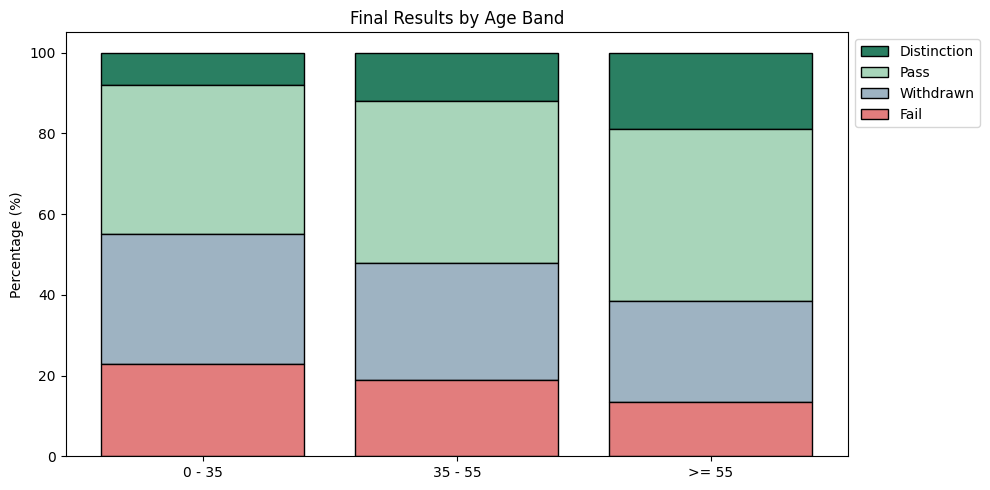

In [19]:
# Stacked bar chart showing percentage breakdown of final results by age band

import matplotlib.pyplot as plt

# Prepare data
age_bands = ['0 - 35', '35 - 55', '>= 55']
distinction = [8.1, 11.9, 19]
pass_ = [36.9, 40.3, 42.6]
fail = [22.8, 19, 13.4]
withdrawn = [32.2, 28.8, 25]

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']  # Distinction, Pass, Fail, Withdrawn

plt.figure(figsize=(10, 5))

p1 = plt.bar(age_bands, distinction, bottom=[i+j+k for i,j,k in zip(fail, withdrawn, pass_)], label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(age_bands, pass_, bottom=[i+j for i,j in zip(fail, withdrawn)], label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(age_bands, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(age_bands, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Age Band')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust layout to prevent overlap

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/final_results_by_age_band.png", bbox_inches='tight')
plt.show()

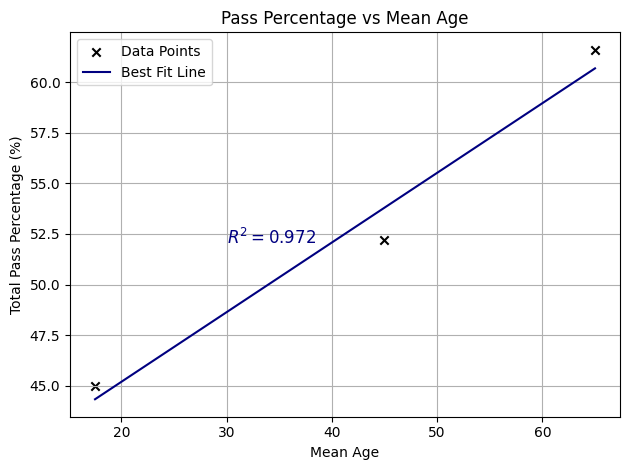

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.array([17.5, 45, 65])
y = np.array([45, 52.2, 61.6])

# Regression parameters
m = 0.3442
c = 38.31
r_squared = 0.9723

# Line
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

# Plot
plt.scatter(x, y, color='black', marker='x', label='Data Points')
plt.plot(x_line, y_line, color='navy', label='Best Fit Line')

plt.xlabel('Mean Age')
plt.ylabel('Total Pass Percentage (%)')
plt.title('Pass Percentage vs Mean Age')
plt.legend()

plt.text(
    x=30, 
    y=52, 
    s=r'$R^2 = {:.3f}$'.format(r_squared), 
    fontsize=12, 
    color='navy'
)

plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/regression/regression_mean_age.png", bbox_inches='tight')


plt.show()

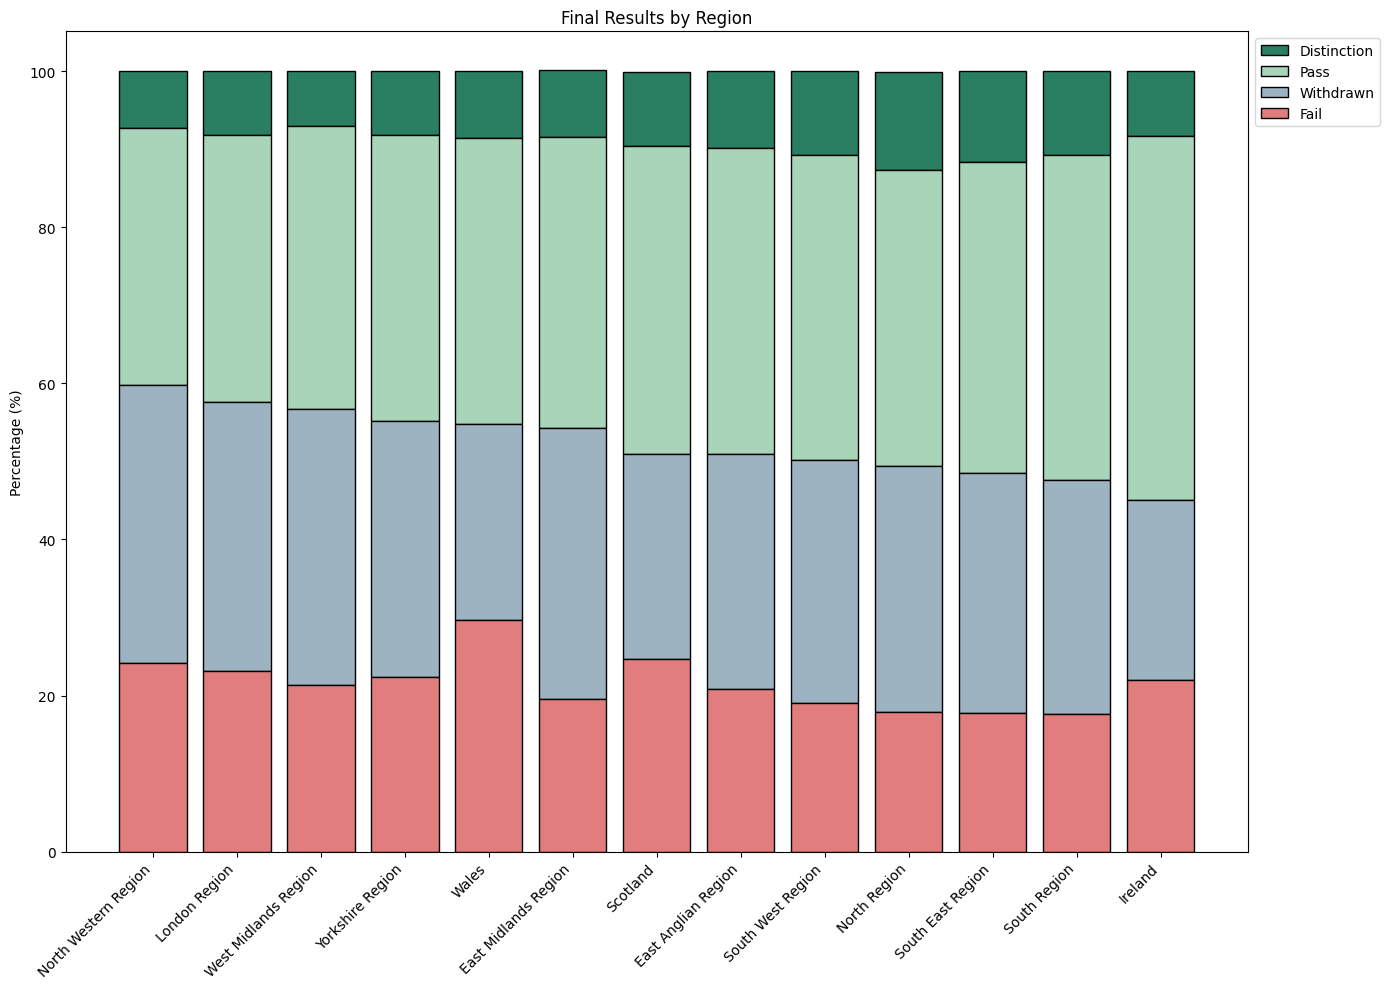

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Data
regions = [
    'Scotland', 'East Anglian Region', 'London Region', 'South Region', 'North Western Region',
    'West Midlands Region', 'South West Region', 'East Midlands Region', 'South East Region',
    'Wales', 'Yorkshire Region', 'North Region', 'Ireland'
]

distinction = np.array([9.5, 9.8, 8.2, 10.8, 7.3, 7.0, 10.8, 8.5, 11.6, 8.5, 8.2, 12.6, 8.3])
pass_ = np.array([39.4, 39.2, 34.2, 41.6, 32.9, 36.3, 39.0, 37.3, 39.9, 36.7, 36.6, 37.9, 46.6])
fail = np.array([24.7, 20.9, 23.1, 17.6, 24.2, 21.3, 19.1, 19.5, 17.8, 29.7, 22.4, 17.9, 22.0])
withdrawn = np.array([26.3, 30.1, 34.5, 30.0, 35.6, 35.4, 31.1, 34.8, 30.7, 25.1, 32.8, 31.5, 23.1])

# Calculate combined pass + distinction rates
combined_pass = distinction + pass_

# Get sorted indices
sorted_indices = np.argsort(combined_pass)

# Sort all arrays by combined pass + distinction
regions_sorted = [regions[i] for i in sorted_indices]
distinction_sorted = distinction[sorted_indices]
pass_sorted = pass_[sorted_indices]
fail_sorted = fail[sorted_indices]
withdrawn_sorted = withdrawn[sorted_indices]

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']  # Distinction, Pass, Fail, Withdrawn

plt.figure(figsize=(14,10))

p1 = plt.bar(regions_sorted, distinction_sorted, bottom=fail_sorted + withdrawn_sorted + pass_sorted, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(regions_sorted, pass_sorted, bottom=fail_sorted + withdrawn_sorted, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(regions_sorted, withdrawn_sorted, bottom=fail_sorted, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(regions_sorted, fail_sorted, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Region')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_by_region.png", bbox_inches='tight')

plt.show()

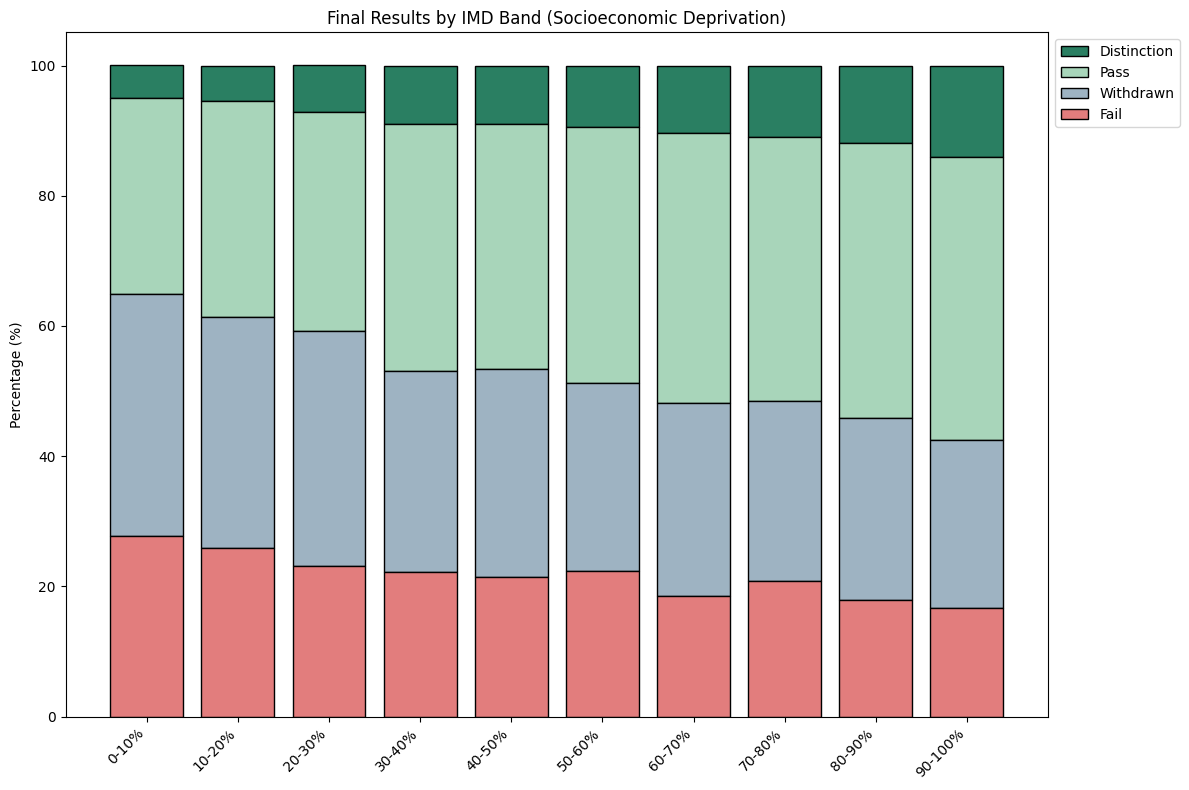

In [22]:
import matplotlib.pyplot as plt
import numpy as np

imd_bands = [
    '0-10%', '10-20%', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]

distinction = np.array([5.1, 5.4, 7.2, 8.9, 9, 9.5, 10.3, 10.9, 11.9, 14.1])
pass_ = np.array([30.1, 33.2, 33.6, 38.0, 37.6, 39.3, 41.6, 40.6, 42.2, 43.4])
fail = np.array([27.7, 25.9, 23.1, 22.2, 21.4, 22.4, 18.5, 20.8, 17.9, 16.6,])
withdrawn = np.array([37.2, 35.4, 36.2, 30.9, 32.0, 28.8, 29.6, 27.7, 28.0, 25.9])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']

plt.figure(figsize=(12,8))

p1 = plt.bar(imd_bands, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(imd_bands, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(imd_bands, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(imd_bands, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by IMD Band (Socioeconomic Deprivation)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_imd_band.png", bbox_inches='tight')

plt.show()

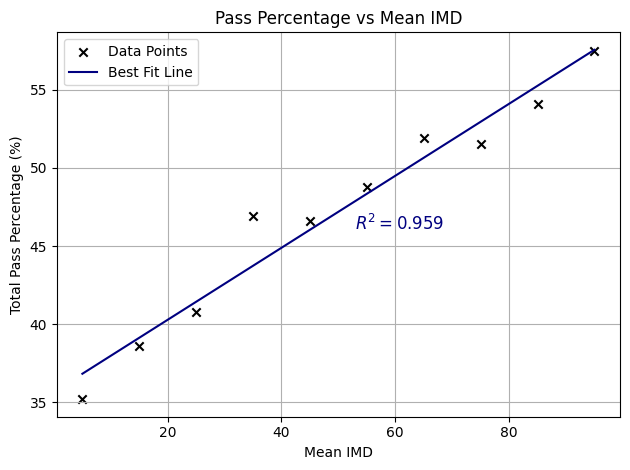

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.array([5, 15, 25, 35, 45, 55, 65, 75, 85, 95])
y = np.array([35.2, 38.6, 40.8, 46.9, 46.6, 48.8, 51.9, 51.5, 54.1, 57.5])

# Regression parameters
m = 0.2302
c = 35.68
r_squared = 0.959

# Regression line
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

# Plot
plt.scatter(x, y, color='black', marker='x', label='Data Points')
plt.plot(x_line, y_line, color='navy', label='Best Fit Line')

plt.xlabel('Mean IMD')
plt.ylabel('Total Pass Percentage (%)')
plt.title('Pass Percentage vs Mean IMD')
plt.legend()

plt.text(
    x=53, 
    y=46, 
    s=r'$R^2 = {:.3f}$'.format(r_squared), 
    fontsize=12, 
    color='navy'
)

plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/regression/regression_mean_imd.png", bbox_inches='tight')

plt.show()

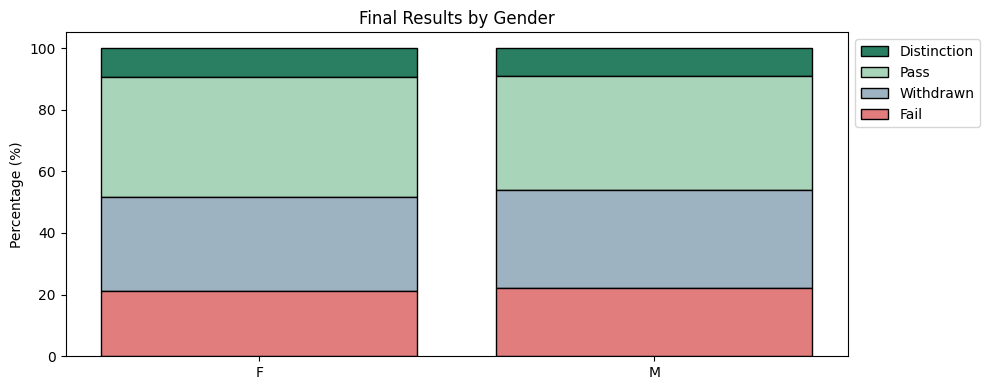

In [24]:
import matplotlib.pyplot as plt
import numpy as np

genders = ['F', 'M']

distinction = np.array([9.5, 9.1])
pass_ = np.array([39.0, 37.1])
fail = np.array([21.1, 22.1])
withdrawn = np.array([30.5, 31.7])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']  # Distinction, Pass, Fail, Withdrawn

plt.figure(figsize=(10, 4))  # Fixed width, smaller height for 2 categories

p4 = plt.bar(genders, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p3 = plt.bar(genders, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p2 = plt.bar(genders, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p1 = plt.bar(genders, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Gender')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_gender.png", bbox_inches='tight')

plt.show()

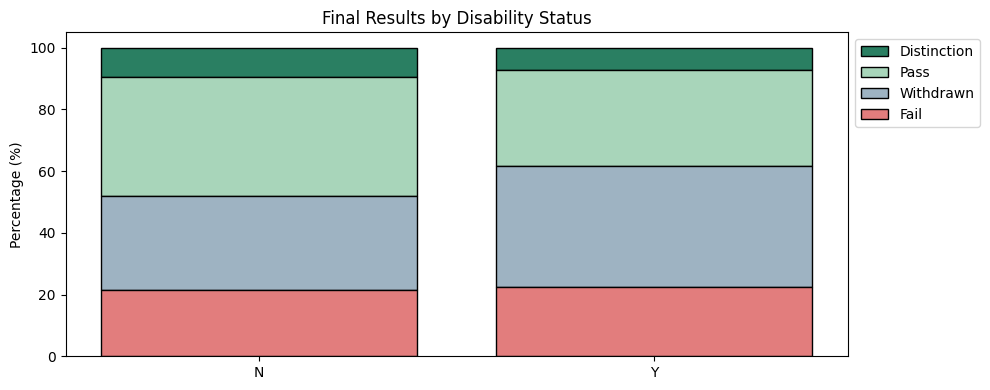

In [25]:
import matplotlib.pyplot as plt
import numpy as np

disability_status = ['N', 'Y']  # No, Yes

distinction = np.array([9.5, 7.0])     # N, Y
pass_ = np.array([38.7, 31.1])         # N, Y
fail = np.array([21.5, 22.5])          # N, Y
withdrawn = np.array([30.3, 39.3])     # N, Y

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']  # Distinction, Pass, Fail, Withdrawn

plt.figure(figsize=(10, 4))  # Fixed width, small height for two categories

p4 = plt.bar(disability_status, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p3 = plt.bar(disability_status, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p2 = plt.bar(disability_status, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p1 = plt.bar(disability_status, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Disability Status')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_disability.png", bbox_inches='tight')

plt.show()


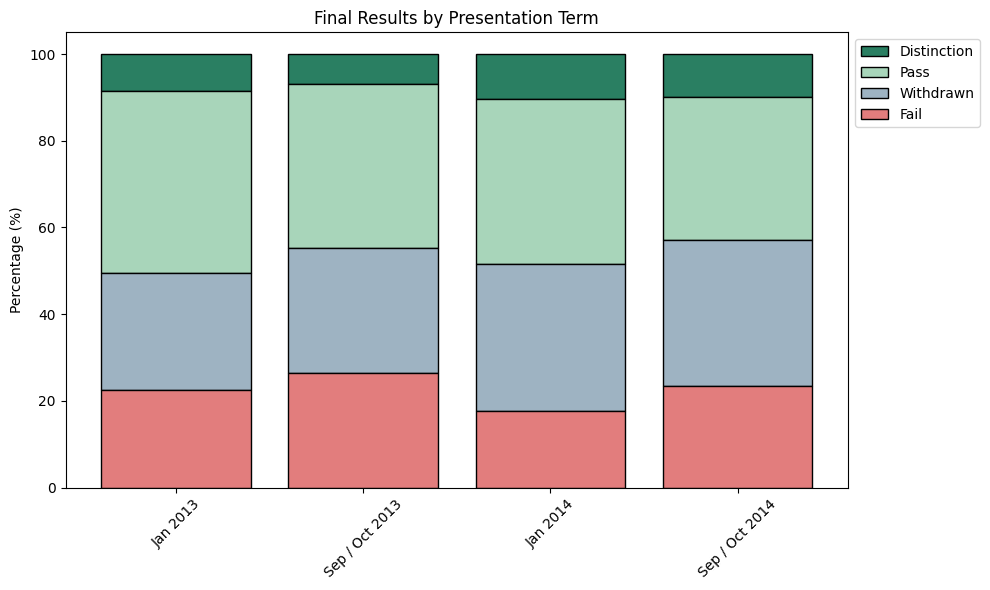

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Chronological order
presentation_codes = ['2013J', '2013B', '2014J', '2014B']

# Corresponding data reordered to match above order
distinction = np.array([8.5, 7, 10.3, 10])
pass_ = np.array([42.1, 37.7, 38.1, 33])
fail = np.array([22.6, 26.5, 17.6, 23.5])
withdrawn = np.array([26.8, 28.8, 34, 33.5])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']

label_map = {
    '2013J': 'Jan 2013',
    '2013B': 'Sep / Oct 2013',
    '2014J': 'Jan 2014',
    '2014B': 'Sep / Oct 2014',
}

labels = [label_map[code] for code in presentation_codes]

plt.figure(figsize=(10, 6))

p1 = plt.bar(presentation_codes, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(presentation_codes, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(presentation_codes, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(presentation_codes, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Presentation Term')
plt.xticks(ticks=range(len(presentation_codes)), labels=labels, rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_presentation_term.png", bbox_inches='tight')

plt.show()

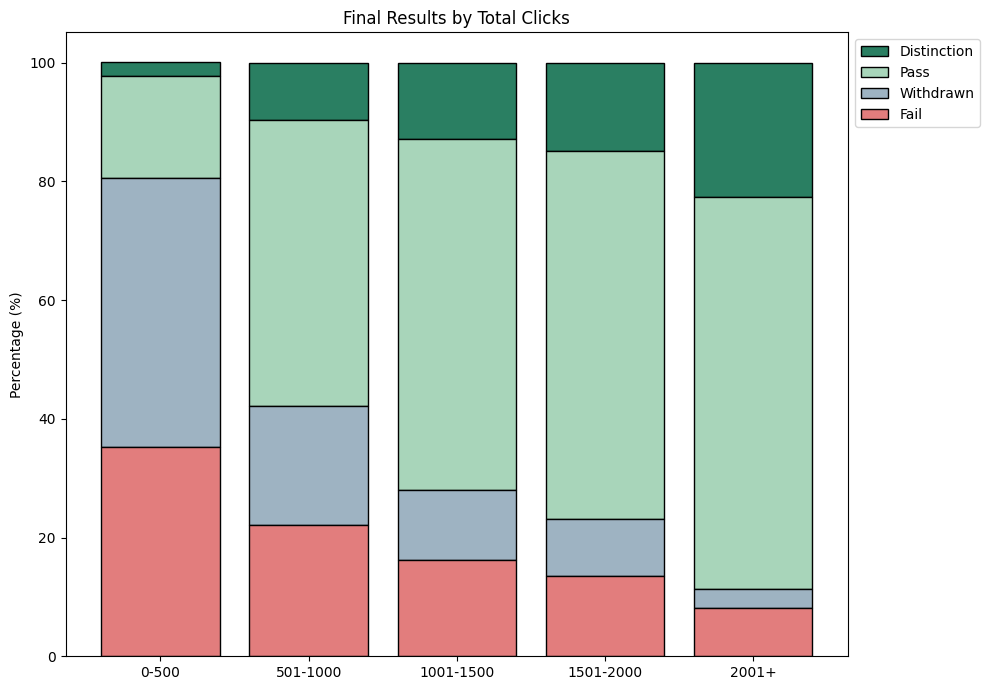

In [27]:
import matplotlib.pyplot as plt
import numpy as np

click_bins = ['0-500', '501-1000', '1001-1500', '1501-2000', '2001+']

distinction = np.array([2.3, 9.7, 12.8, 14.9, 22.5])
pass_ = np.array([17.3, 48.2, 59.1, 61.9, 66.0])
fail = np.array([35.2, 22.1, 16.3, 13.5, 8.1])
withdrawn = np.array([45.3, 20.0, 11.7, 9.7, 3.3])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']

plt.figure(figsize=(10, 7))

p1 = plt.bar(click_bins, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(click_bins, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(click_bins, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(click_bins, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Total Clicks')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_total_clicks.png", bbox_inches='tight')

plt.show()

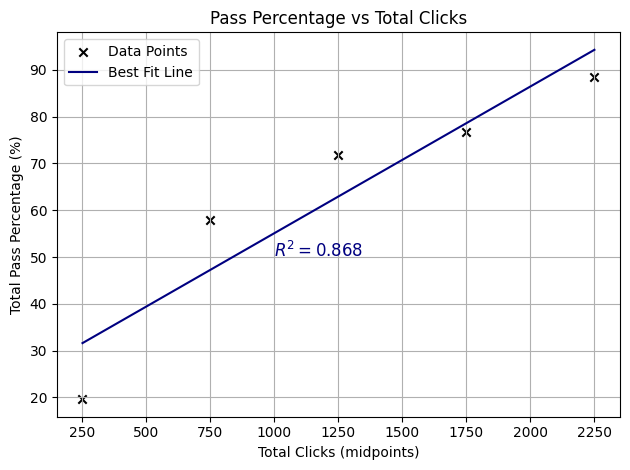

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.array([250, 750, 1250, 1750, 2250])
y = np.array([19.6, 57.9, 71.9, 76.8, 88.5])

# Regression parameters
m = 0.03134
c = 23.765
r_squared = 0.868

# Line points
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

# Plot
plt.scatter(x, y, color='black', marker='x', label='Data Points')
plt.plot(x_line, y_line, color='navy', label='Best Fit Line')

plt.xlabel('Total Clicks (midpoints)')
plt.ylabel('Total Pass Percentage (%)')
plt.title('Pass Percentage vs Total Clicks')
plt.legend()

plt.text(
    x=1000, 
    y=50, 
    s=r'$R^2 = {:.3f}$'.format(r_squared), 
    fontsize=12, 
    color='navy'
)

plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/regression/regression_total_clicks.png", bbox_inches='tight')

plt.show()

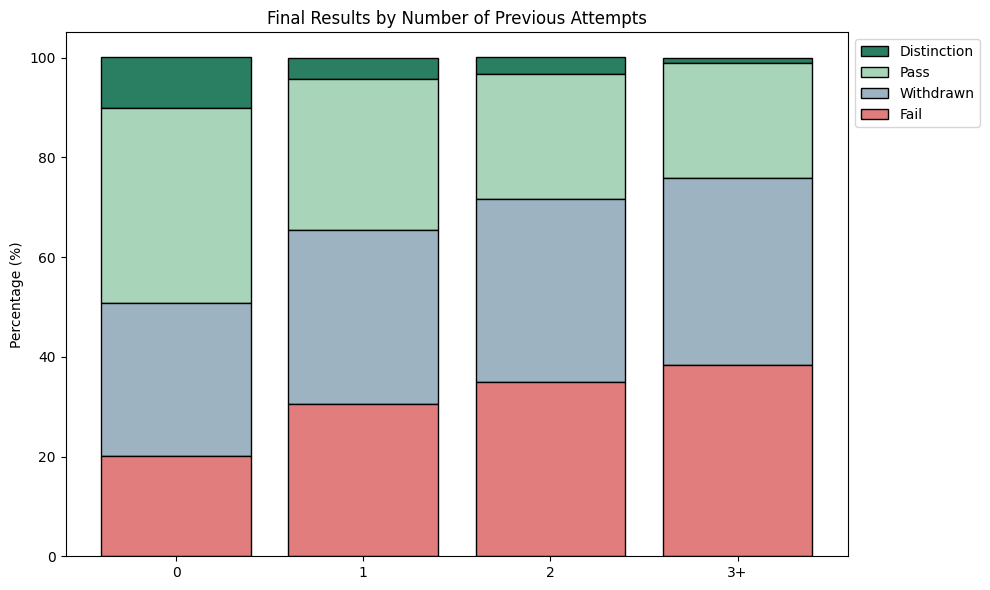

In [29]:
import matplotlib.pyplot as plt
import numpy as np

attempt_bins = ['0', '1', '2', '3+']

distinction = np.array([10.1, 4.3, 3.3, 1.0])
pass_ = np.array([39.2, 30.2, 25.2, 23.2])
fail = np.array([20.2, 30.6, 35.0, 38.4])
withdrawn = np.array([30.6, 34.9, 36.6, 37.4])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']

plt.figure(figsize=(10, 6))

p1 = plt.bar(attempt_bins, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(attempt_bins, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(attempt_bins, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(attempt_bins, fail, label='Fail', color=colors[2], edgecolor='black')

plt.ylabel('Percentage (%)')
plt.title('Final Results by Number of Previous Attempts')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_previous_attempts.png", bbox_inches='tight')

plt.show()

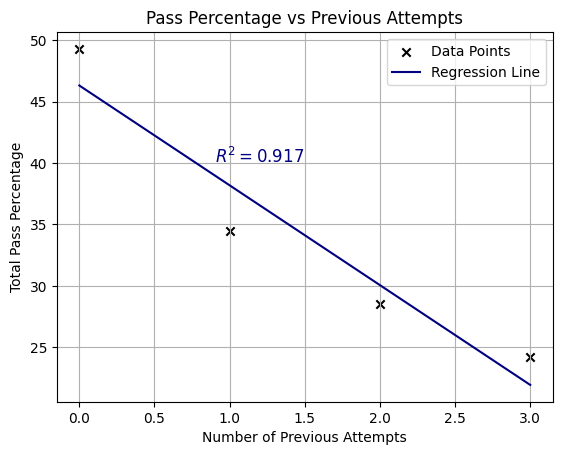

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Data points
x = np.array([0, 1, 2, 3])
y = np.array([49.3, 34.5, 28.5, 24.2])

# Correct regression line parameters
m = -8.13
c = 46.32

# Create line values
x_line = np.linspace(0, 3, 100)
y_line = m * x_line + c

# Plot
plt.scatter(x, y, color='black', label='Data Points', marker ='x')
plt.plot(x_line, y_line, color='navy', label='Regression Line')

plt.text(
    x=0.9,  # x-position (adjust as needed)
    y=40,   # y-position (adjust as needed)
    s=r'$R^2 = 0.917$',  # text with LaTeX formatting
    fontsize=12,
    color='navy'
)

plt.xlabel('Number of Previous Attempts')
plt.ylabel('Total Pass Percentage')
plt.title('Pass Percentage vs Previous Attempts')
plt.legend()
plt.grid(True)

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/regression/regression_previous_attempts.png", bbox_inches='tight')

plt.show()

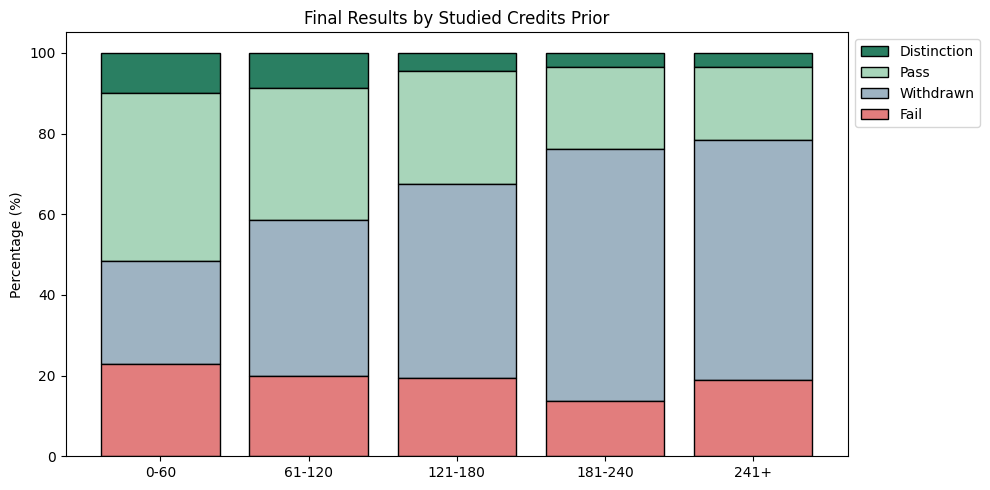

In [31]:
import matplotlib.pyplot as plt
import numpy as np

credits_bins = ['0-60', '61-120', '121-180', '181-240', '241+']

distinction = np.array([10.1, 8.7, 4.4, 3.5, 3.4])
pass_ = np.array([41.7, 32.8, 28.2, 20.2, 18.1])
fail = np.array([22.9, 19.8, 19.5, 13.6, 19.0])
withdrawn = np.array([25.4, 38.7, 47.9, 62.6, 59.5])

colors = ['#2a7f62', '#a8d5ba', '#e27d7d', '#9eb3c2']

# Number of bars = 5 → figsize (10,5) from sizing system
plt.figure(figsize=(10, 5))

p1 = plt.bar(credits_bins, distinction, bottom=fail + withdrawn + pass_, label='Distinction', color=colors[0], edgecolor='black')
p2 = plt.bar(credits_bins, pass_, bottom=fail + withdrawn, label='Pass', color=colors[1], edgecolor='black')
p3 = plt.bar(credits_bins, withdrawn, bottom=fail, label='Withdrawn', color=colors[3], edgecolor='black')
p4 = plt.bar(credits_bins, fail, label='Fail', color=colors[2], edgecolor='black')



plt.ylabel('Percentage (%)')
plt.title('Final Results by Studied Credits Prior')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()



plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/stacked/final_results_prior_credits.png", bbox_inches='tight')

plt.show()

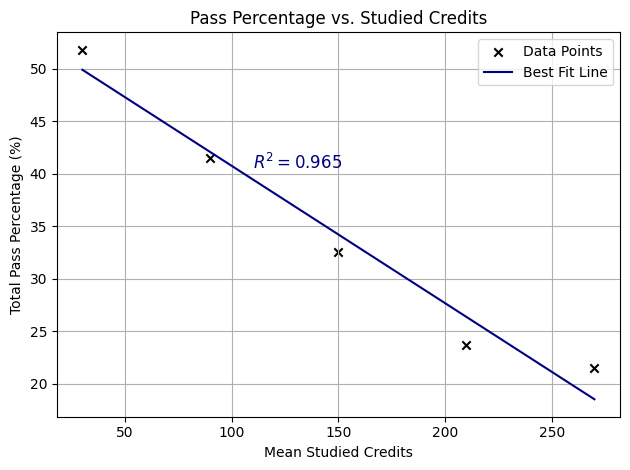

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data
x = np.array([30, 90, 150, 210, 270])
y = np.array([51.8, 41.5, 32.6, 23.7, 21.5])

# Regression line parameters
m = -0.130666667
c = 53.82
r_squared = 0.9647  # Rounded for display

# Create values for the regression line
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

# Plot
plt.scatter(x, y, color='black', marker='x', label='Data Points')
plt.plot(x_line, y_line, color='navy', label='Best Fit Line')

plt.xlabel('Mean Studied Credits')
plt.ylabel('Total Pass Percentage (%)')
plt.title('Pass Percentage vs. Studied Credits')
plt.legend()

# Add R^2 annotation on plot
plt.text(
    x=110, 
    y=40.5, 
    s=r'$R^2 = {:.3f}$'.format(r_squared), 
    fontsize=12, 
    color='navy'
)

plt.grid(True)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/regression/regression_prior_credits.png", bbox_inches='tight')

plt.show()


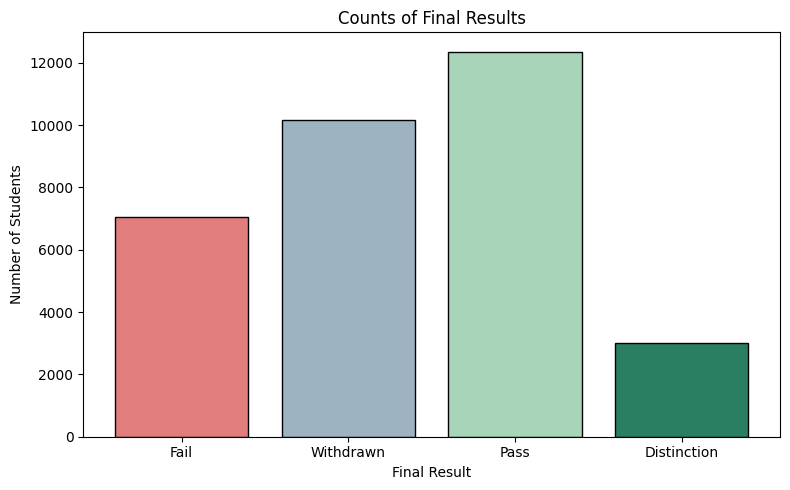

In [33]:
import matplotlib.pyplot as plt

# Define the order and colors
order = ['Fail', 'Withdrawn', 'Pass', 'Distinction']
colors = ['#e27d7d', '#9eb3c2', '#a8d5ba', '#2a7f62']  # Fail, Withdrawn, Pass, Distinction

# Count results in the specified order
counts = df['final_result'].value_counts().reindex(order)

plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black')

plt.title('Counts of Final Results')
plt.ylabel('Number of Students')
plt.xlabel('Final Result')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/outcome_distributions/final_results_counts.png", bbox_inches='tight')


plt.show()

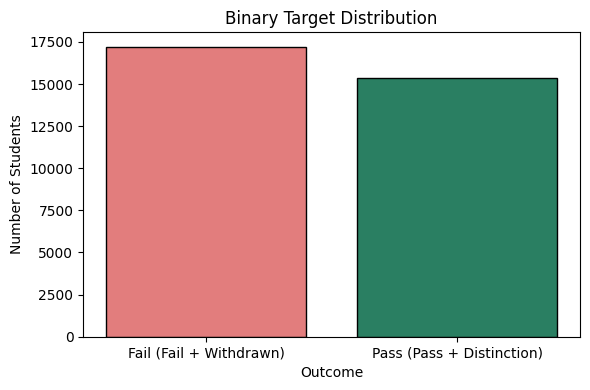

In [34]:
# Create binary target column: Pass=1 (Pass + Distinction), Fail=0 (Fail + Withdrawn)
df['binary_target'] = df['final_result'].apply(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Define colors for binary target (Fail left, Pass right)
binary_colors = ['#e27d7d', '#2a7f62']  # Fail (red), Pass (dark green)

# Count binary target values
binary_counts = df['binary_target'].value_counts().sort_index()  # 0 then 1


plt.figure(figsize=(6,4))
bars = plt.bar(['Fail (Fail + Withdrawn)', 'Pass (Pass + Distinction)'], binary_counts.values,
               color=binary_colors, edgecolor='black')

plt.title('Binary Target Distribution')
plt.ylabel('Number of Students')
plt.xlabel('Outcome')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/outcome_distributions/binary_target_distribution.png", bbox_inches='tight')


plt.show()

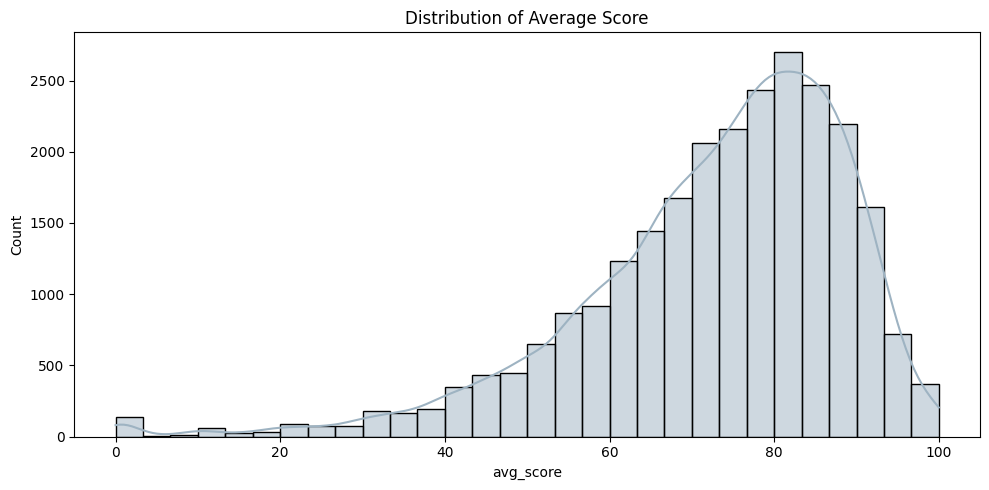

/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/4020127379.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binary_target', y='avg_score', data=df, palette=['#e27d7d', '#2a7f62'])


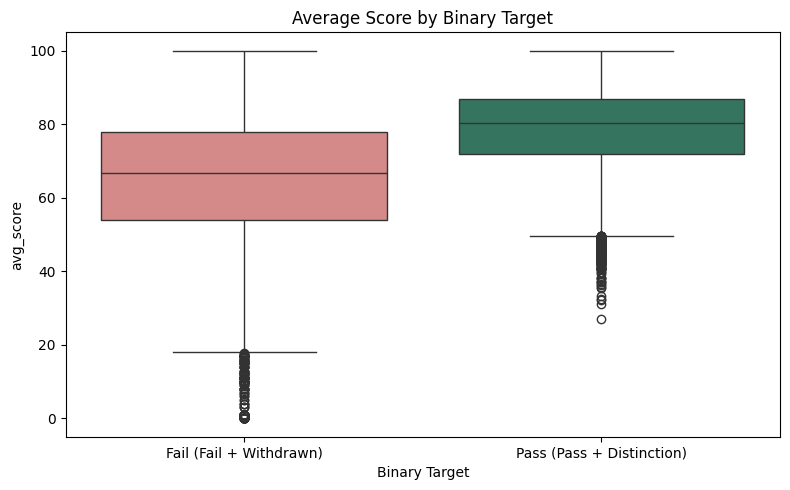

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram + KDE for avg_score
plt.figure(figsize=(10,5))
sns.histplot(df['avg_score'], kde=True, bins=30, color='#9eb3c2')
plt.title('Distribution of Average Score')
plt.xlabel('avg_score')
plt.ylabel('Count')
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/avg_score_distribution.png", bbox_inches='tight')

plt.show()

# Boxplot of avg_score by binary target
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_target', y='avg_score', data=df, palette=['#e27d7d', '#2a7f62'])
plt.title('Average Score by Binary Target')
plt.xlabel('Binary Target')
plt.ylabel('avg_score')
plt.xticks([0,1], ['Fail (Fail + Withdrawn)', 'Pass (Pass + Distinction)'])
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/avg_score_boxplot.png", bbox_inches='tight')

plt.show()


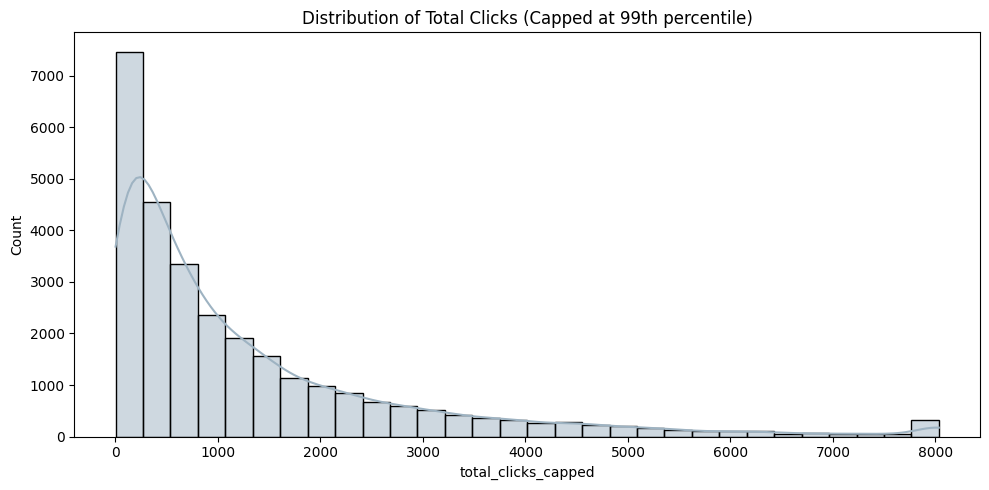

/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/1581492208.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binary_target', y='total_clicks_capped', data=df, palette=['#e27d7d', '#2a7f62'])


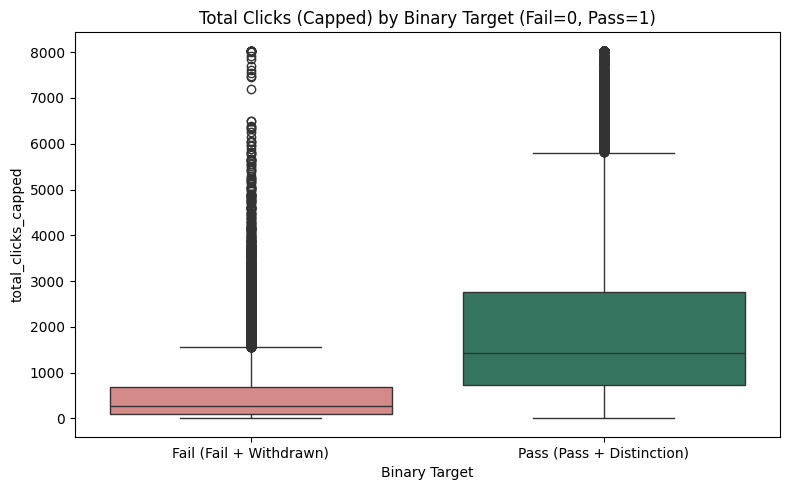

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute 99th percentile value for total_clicks
cap_value = df['total_clicks'].quantile(0.99)

# Create capped clicks column
df['total_clicks_capped'] = df['total_clicks'].clip(upper=cap_value)

# Histogram + KDE for capped total_clicks
plt.figure(figsize=(10,5))
sns.histplot(df['total_clicks_capped'], kde=True, bins=30, color='#9eb3c2')
plt.title('Distribution of Total Clicks (Capped at 99th percentile)')
plt.xlabel('total_clicks_capped')
plt.ylabel('Count')
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/total_clicks_distribution.png", bbox_inches='tight')

plt.show()

# Boxplot of capped total_clicks by binary target
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_target', y='total_clicks_capped', data=df, palette=['#e27d7d', '#2a7f62'])
plt.title('Total Clicks (Capped) by Binary Target (Fail=0, Pass=1)')
plt.xlabel('Binary Target')
plt.ylabel('total_clicks_capped')
plt.xticks([0,1], ['Fail (Fail + Withdrawn)', 'Pass (Pass + Distinction)'])
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/total_clicks_boxplot.png", bbox_inches='tight')

plt.show()

/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/3704235940.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binary_target', y='num_assessments', data=df, palette=['#e27d7d', '#2a7f62'])


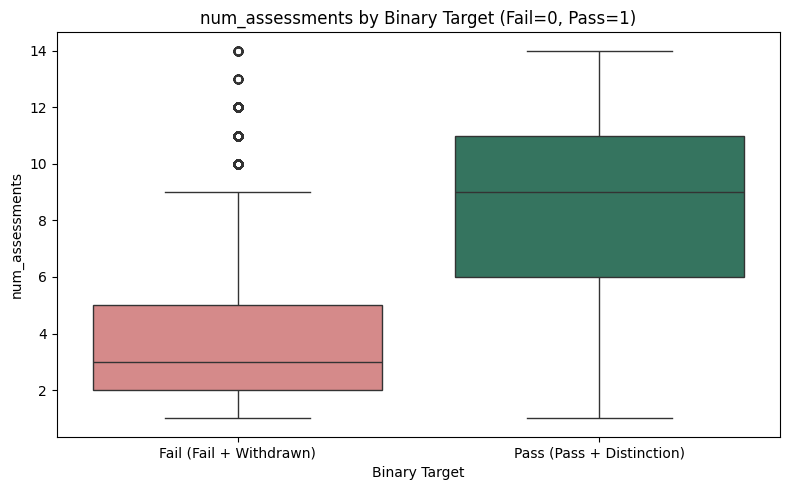

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot of num_assessments by binary target
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_target', y='num_assessments', data=df, palette=['#e27d7d', '#2a7f62'])
plt.title('num_assessments by Binary Target (Fail=0, Pass=1)')
plt.xlabel('Binary Target')
plt.ylabel('num_assessments')
plt.xticks([0,1], ['Fail (Fail + Withdrawn)', 'Pass (Pass + Distinction)'])
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/num_assessments_boxplot.png", bbox_inches='tight')

plt.show()


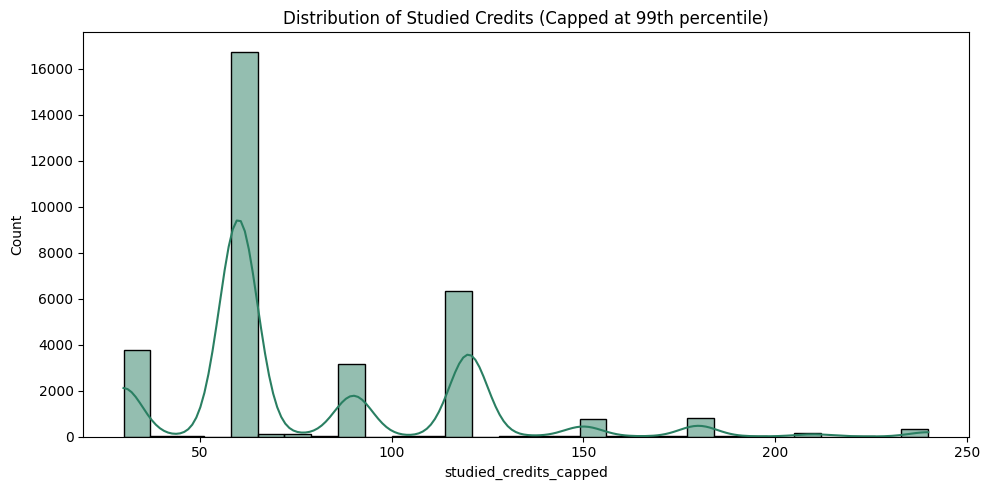

/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/3610929858.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='binary_target', y='studied_credits_capped', data=df, palette=['#e27d7d', '#2a7f62'])


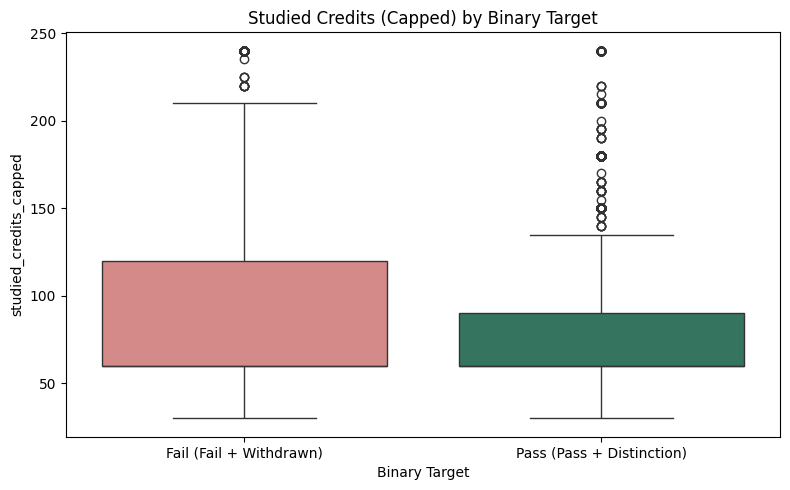

In [38]:
# Calculate 99th percentile cap for studied_credits
cap_value = df['studied_credits'].quantile(0.99)

# Create capped studied_credits column
df['studied_credits_capped'] = df['studied_credits'].clip(upper=cap_value)

# Histogram + KDE for capped studied_credits
plt.figure(figsize=(10,5))
sns.histplot(df['studied_credits_capped'], kde=True, bins=30, color='#2a7f62')
plt.title('Distribution of Studied Credits (Capped at 99th percentile)')
plt.xlabel('studied_credits_capped')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Boxplot of capped studied_credits by binary target
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_target', y='studied_credits_capped', data=df, palette=['#e27d7d', '#2a7f62'])
plt.title('Studied Credits (Capped) by Binary Target')
plt.xlabel('Binary Target')
plt.ylabel('studied_credits_capped')
plt.xticks([0,1], ['Fail (Fail + Withdrawn)', 'Pass (Pass + Distinction)'])
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/studied_credits_boxplot.png", bbox_inches='tight')

plt.show()

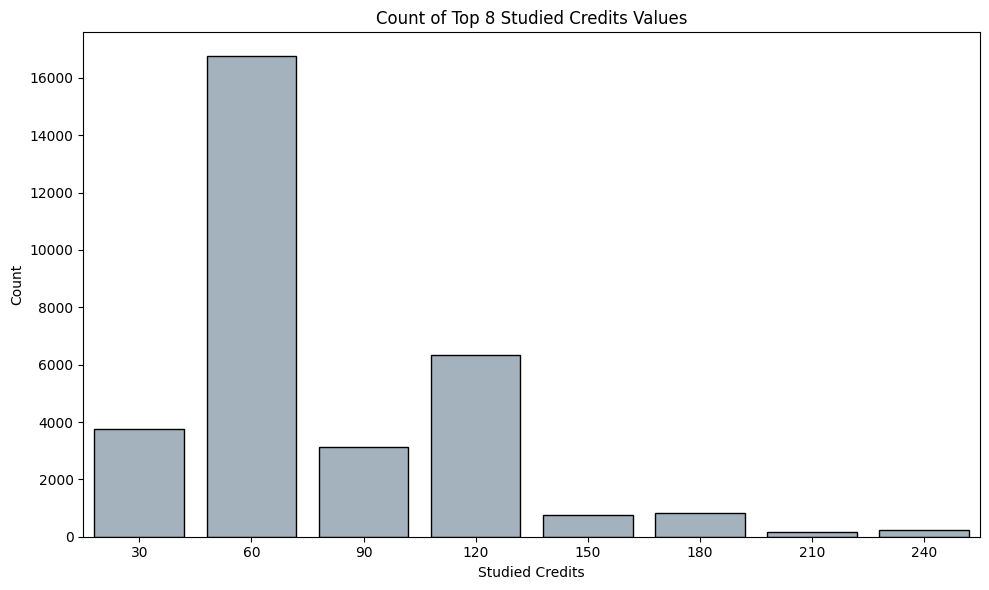

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define color and outline
bar_color = '#9eb3c2'  # Neutral blue-grey
edge_color = 'black'

# Find top 8 most common studied_credits values
top_credits = df['studied_credits'].value_counts().nlargest(8).index.tolist()

# Filter dataframe for only those top credits
df_top_credits = df[df['studied_credits'].isin(top_credits)]

# Plot count plot with outline and specified color
plt.figure(figsize=(10,6))
bars = sns.countplot(
    data=df_top_credits,
    x='studied_credits',
    color=bar_color,
    order=sorted(top_credits),
    edgecolor=edge_color
)
plt.title('Count of Top 8 Studied Credits Values')
plt.xlabel('Studied Credits')
plt.ylabel('Count')
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/studied_credits_count.png", bbox_inches='tight')


plt.show()


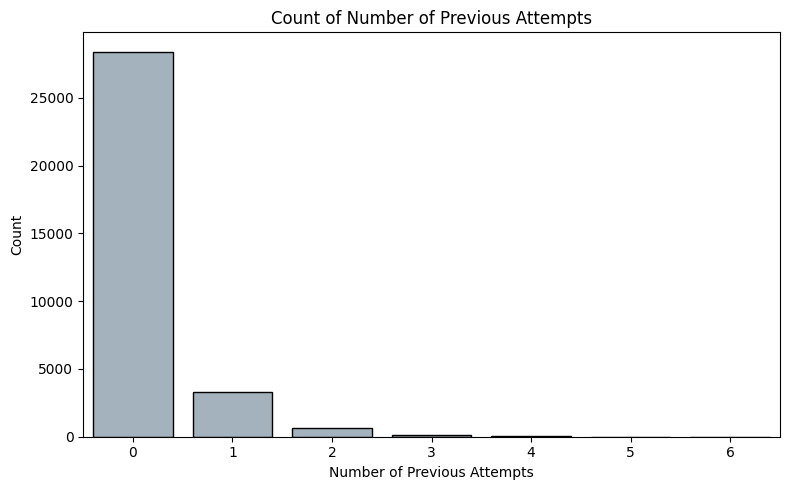

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='num_of_prev_attempts', color='#9eb3c2', edgecolor='black')
plt.title('Count of Number of Previous Attempts')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Count')
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/numeric_features/previous_attempts_count.png", bbox_inches='tight')

plt.show()

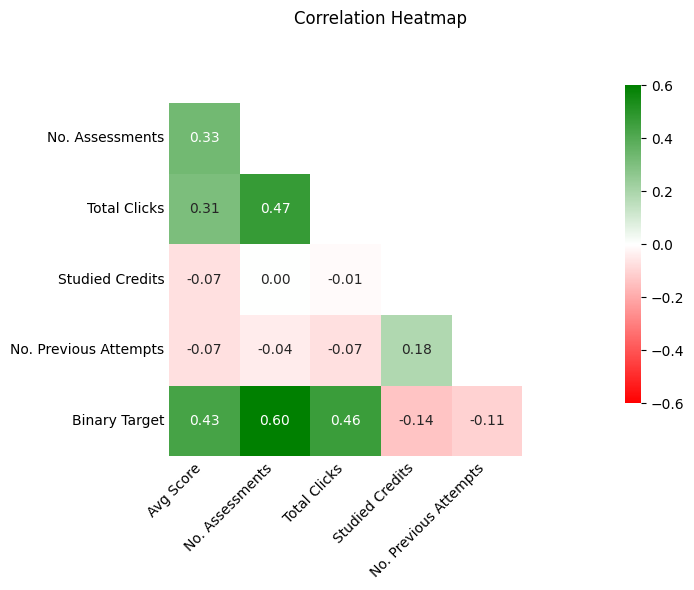

In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

num_cols = ['avg_score', 'num_assessments', 'total_clicks_capped', 
            'studied_credits_capped', 'num_of_prev_attempts', 'binary_target']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = LinearSegmentedColormap.from_list('RedWhiteGreen', ['red', 'white', 'green'])

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    mask=mask,
    square=True,
    center=0,
    vmin=-0.6,
    vmax=0.6,
    cbar_kws={"shrink": 0.75}
)


plt.title('Correlation Heatmap')

# Map original names to capitalized labels
label_map = {
    'avg_score': 'Avg Score',
    'num_assessments': 'No. Assessments',
    'total_clicks_capped': 'Total Clicks',
    'studied_credits_capped': 'Studied Credits',
    'num_of_prev_attempts': 'No. Previous Attempts',
    'binary_target': 'Binary Target'
}

# Get current tick labels
orig_xticklabels = [label.get_text() for label in ax.get_xticklabels()]
orig_yticklabels = [label.get_text() for label in ax.get_yticklabels()]

# Build new labels, but keep 'Avg Score' and 'Binary Target' as white
new_xticklabels = []
for lbl in orig_xticklabels:
    if lbl == 'binary_target':
        new_xticklabels.append('Binary Target')  # text stays the same
    else:
        new_xticklabels.append(label_map.get(lbl, lbl))

new_yticklabels = []
for lbl in orig_yticklabels:
    if lbl == 'avg_score':
        new_yticklabels.append('Avg Score')
    else:
        new_yticklabels.append(label_map.get(lbl, lbl))

# Set x tick labels with rotation
ax.set_xticklabels(new_xticklabels, rotation=45, ha='right')

# Set y tick labels without rotation
ax.set_yticklabels(new_yticklabels, rotation=0)

# Now explicitly set colors: make 'Avg Score' y-label and 'Binary Target' x-label white, others default
for label in ax.get_yticklabels():
    if label.get_text() == 'Avg Score':
        label.set_color('white')

for label in ax.get_xticklabels():
    if label.get_text() == 'Binary Target':
        label.set_color('white')

ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)

plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/feature_relationships/correlation_heatmap.png", bbox_inches='tight')

plt.show()


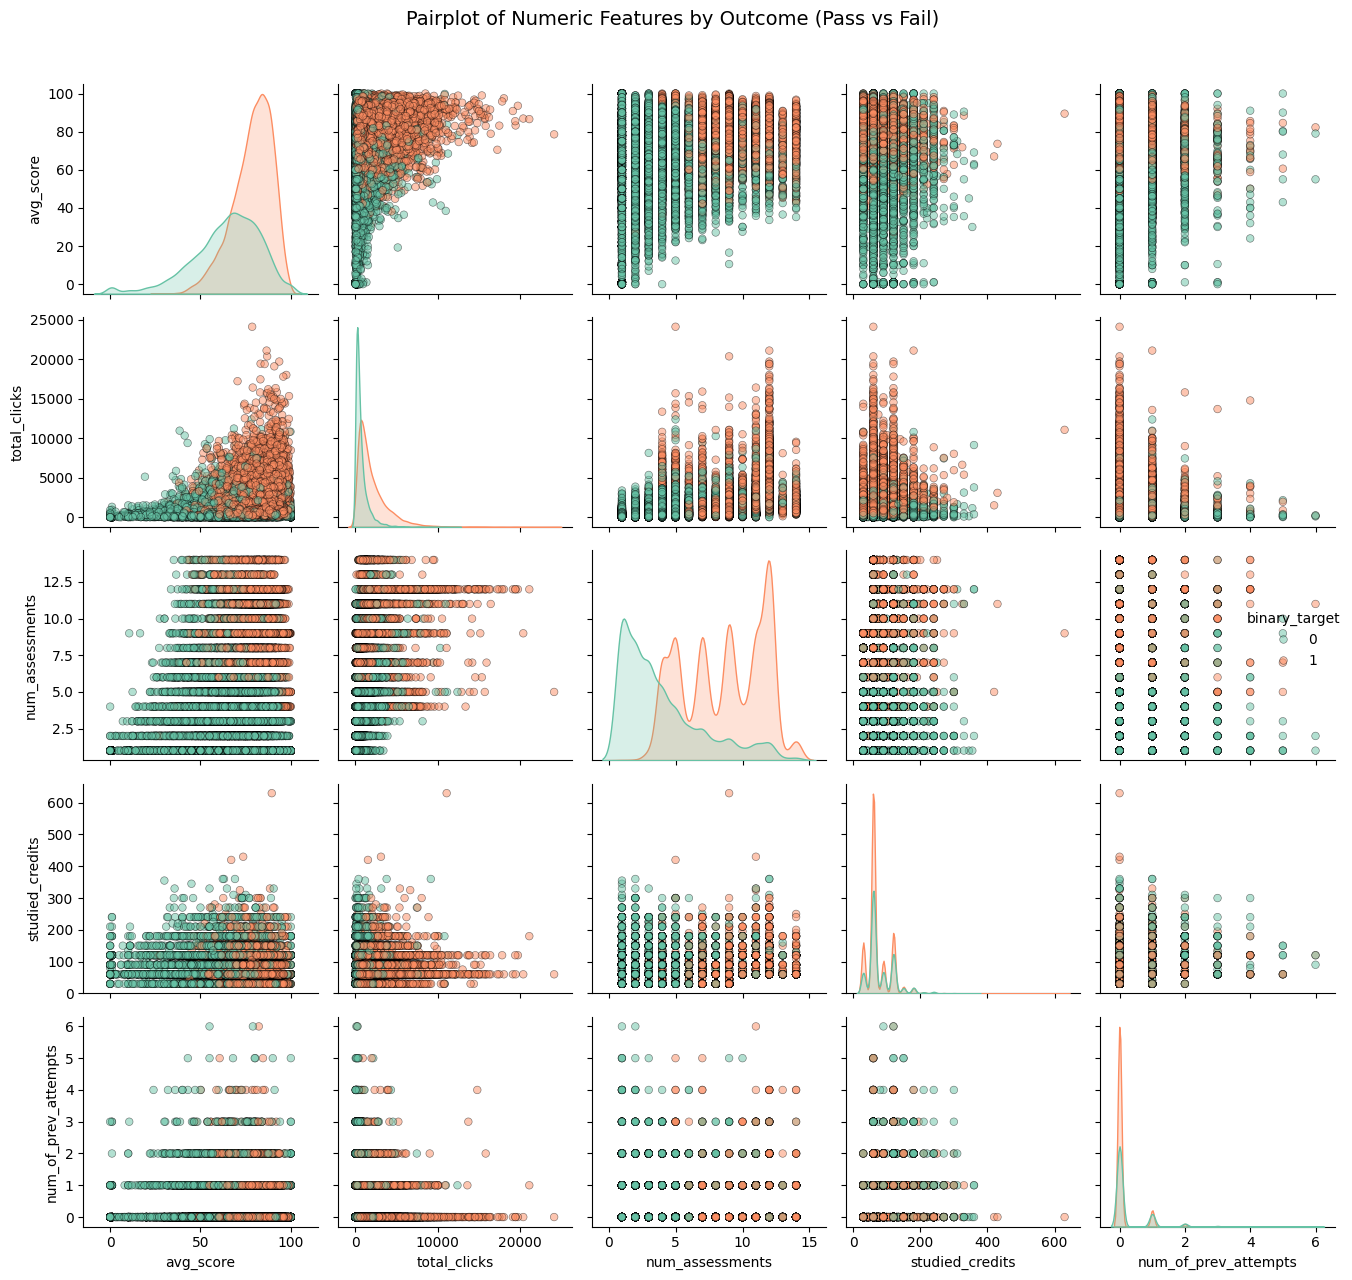

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Create binary target: 1 = Pass or Distinction, 0 = Fail or Withdrawn
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Select relevant numeric features
features = [
    'avg_score',
    'total_clicks',
    'num_assessments',
    'studied_credits',
    'num_of_prev_attempts',
    'binary_target'
]

# Drop rows with missing values
df_pairplot = df[features].dropna()

# Create pairplot
sns.pairplot(
    df_pairplot,
    hue='binary_target',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'edgecolor': 'k', 's': 30}
)

# Title + layout
plt.suptitle('Pairplot of Numeric Features by Outcome (Pass vs Fail)', y=1.02, fontsize=14)
plt.tight_layout()

plt.savefig("/Users/jamesjackson/Documents/student_outcome_analysis/data/Visualisations/feature_relationships/pair_plot.png", dpi=300, bbox_inches='tight')


plt.show()


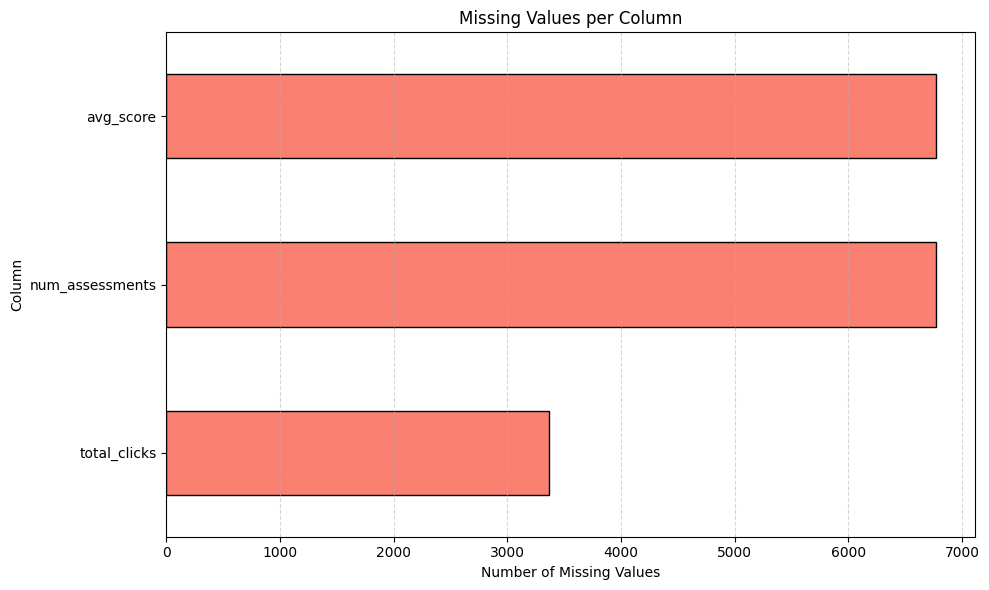

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Count missing values per column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
missing_counts.plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Missing Values per Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')
plt.gca().invert_yaxis()  # Largest on top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()


plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/missing_values.png', bbox_inches='tight')

plt.show()


In [44]:
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)


df['avg_score_missing'] = df['avg_score'].isnull()
missing_by_result = df.groupby(['final_result', 'avg_score_missing']).size().unstack()
print(missing_by_result)


avg_score_missing    False   True 
final_result                      
Distinction         3024.0     NaN
Fail                5765.0  1287.0
Pass               12358.0     3.0
Withdrawn           4673.0  5483.0


In [45]:
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)


df['num_assessments_missing'] = df['num_assessments'].isnull()
missing_by_result = df.groupby(['final_result', 'num_assessments_missing']).size().unstack()
print(missing_by_result)


num_assessments_missing    False   True 
final_result                            
Distinction               3024.0     NaN
Fail                      5765.0  1287.0
Pass                     12358.0     3.0
Withdrawn                 4673.0  5483.0


In [46]:
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)


df['total_clicks_missing'] = df['total_clicks'].isnull()
missing_by_result = df.groupby(['final_result', 'total_clicks_missing']).size().unstack()
print(missing_by_result)


total_clicks_missing    False   True 
final_result                         
Distinction            3024.0     NaN
Fail                   6678.0   374.0
Pass                  12358.0     3.0
Withdrawn              7168.0  2988.0


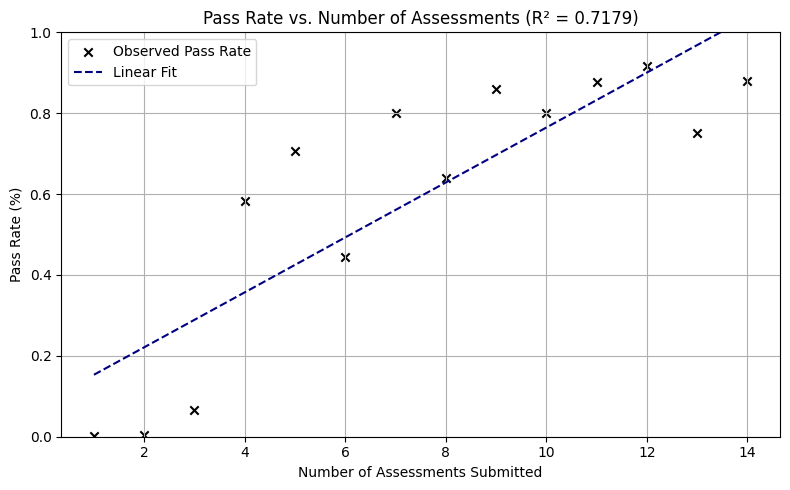

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Binary target
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Drop nulls
df_clean = df[['num_assessments', 'binary_target']].dropna()

# Group by num_assessments
grouped = df_clean.groupby('num_assessments')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# Fit regression on pass_rate vs num_assessments
X = grouped[['num_assessments']]
y = grouped['pass_rate']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Observed Pass Rate', marker ='x')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Number of Assessments Submitted')
plt.ylabel('Pass Rate (%)')
plt.title(f'Pass Rate vs. Number of Assessments (R² = {r2:.4f})')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()


plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/number_of_assessments_r2.png', bbox_inches='tight')

plt.show()

/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/1754590210.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_clean.groupby('click_bin')['binary_target'].agg(['mean', 'count']).reset_index()


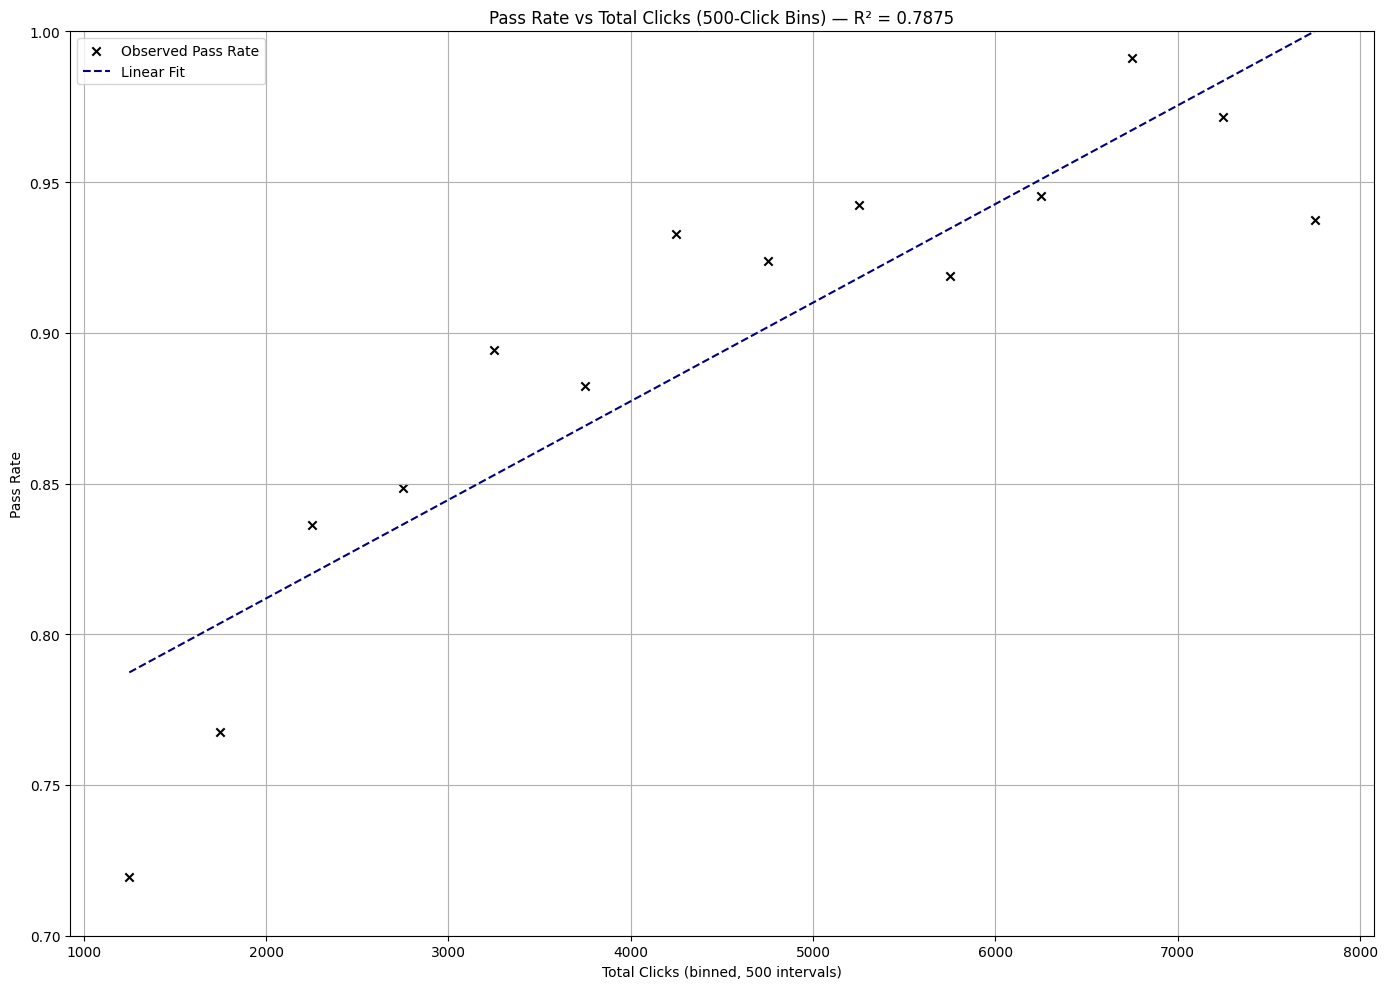

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Binary target
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Drop rows with missing clicks or target
df_clean = df[['total_clicks', 'binary_target']].dropna()
# Keep total_clicks between 1,000 and 8,000
df_clean = df_clean[(df_clean['total_clicks'] >= 1000) & (df_clean['total_clicks'] <= 8000)]


# Create bins of size 500
bin_size = 500
max_clicks = int(df_clean['total_clicks'].max())
bins = list(range(0, max_clicks + bin_size, bin_size))

# Assign bin labels
df_clean['click_bin'] = pd.cut(df_clean['total_clicks'], bins=bins, right=False)

# Group by bin and calculate pass rate
grouped = df_clean.groupby('click_bin')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# For regression, use midpoint of each bin
grouped['bin_midpoint'] = grouped['click_bin'].apply(lambda x: x.left + bin_size / 2)

# Fit linear regression
# Drop bins with no students (NaN pass_rate)
grouped = grouped.dropna(subset=['pass_rate'])

# Fit linear regression
X = grouped[['bin_midpoint']]
y = grouped['pass_rate']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(X, y, color='black', label='Observed Pass Rate', marker ='x')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Total Clicks (binned, 500 intervals)')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate vs Total Clicks (500-Click Bins) — R² = {r2:.4f}')
plt.ylim(0.7, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/total_clicks_r2.png', bbox_inches='tight')


plt.show()


/var/folders/gn/c_sb1q453nl00mmq3nrdxfp40000gn/T/ipykernel_35017/726613591.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_clean.groupby('score_bin')['binary_target'].agg(['mean', 'count']).reset_index()


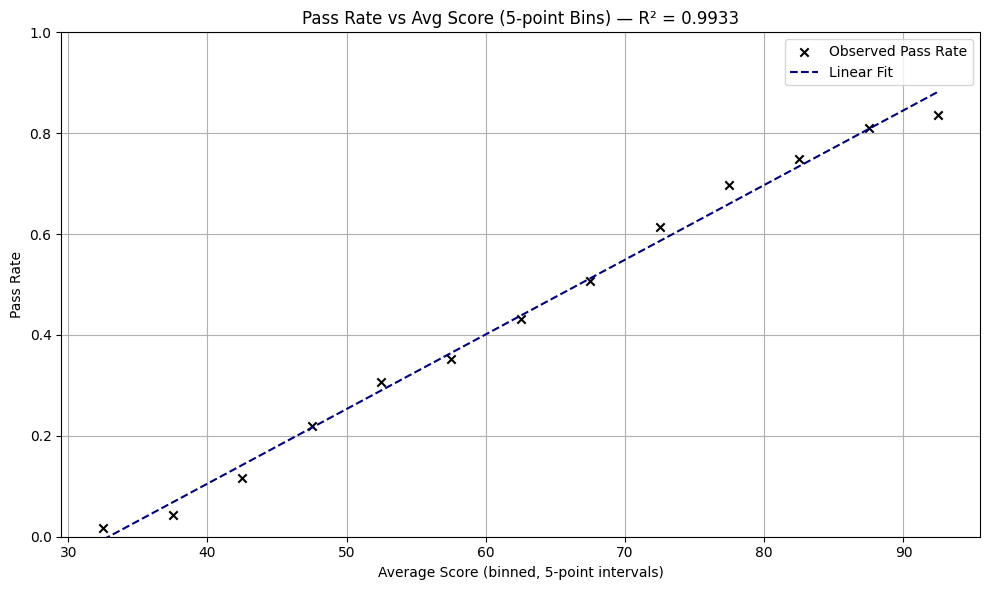

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Binary target
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Filter rows with avg_score less than 95 and greater or equal to 30, drop NaNs for avg_score and binary_target
df_clean = df[['avg_score', 'binary_target']].dropna()
df_clean = df_clean[(df_clean['avg_score'] >= 30) & (df_clean['avg_score'] < 95)]

# Create bins of size 5 (0–100)
bin_size = 5
bins = list(range(0, 101 + bin_size, bin_size))
df_clean['score_bin'] = pd.cut(df_clean['avg_score'], bins=bins, right=False)

# Group and calculate pass rate
grouped = df_clean.groupby('score_bin')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# Bin midpoints for regression
grouped['bin_midpoint'] = grouped['score_bin'].apply(lambda x: x.left + bin_size / 2)

# Remove bins with fewer than 60 students
grouped = grouped[grouped['count'] >= 60]

# Fit regression
X = grouped[['bin_midpoint']]
y = grouped['pass_rate']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', marker='x', label='Observed Pass Rate')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Average Score (binned, 5-point intervals)')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate vs Avg Score (5-point Bins) — R² = {r2:.4f}')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/average_score_r2.png', bbox_inches='tight')

plt.show()


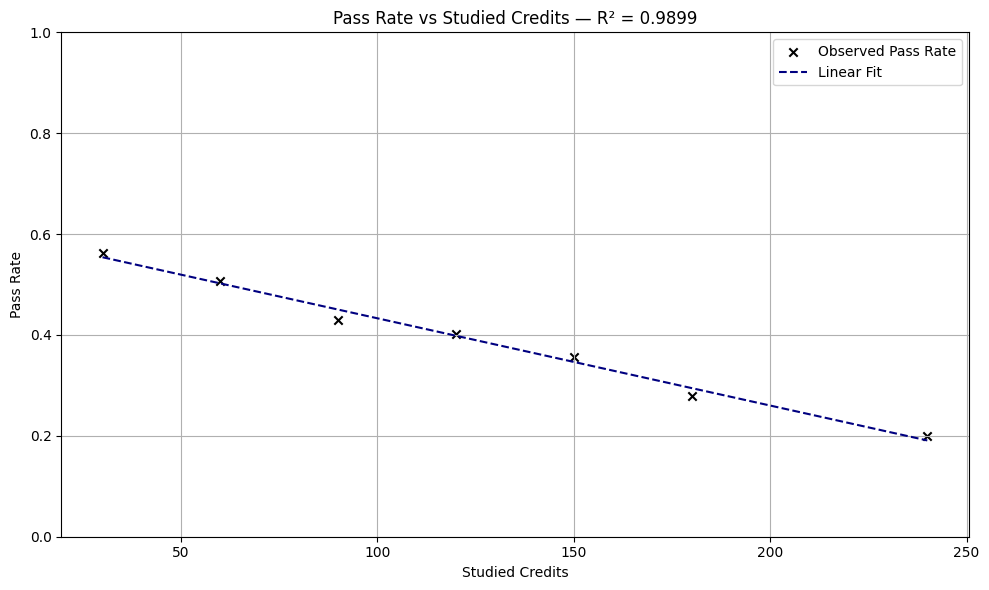

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Define binary target
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Filter to valid credit values
valid_credits = [30, 45, 60, 90, 120, 150, 180, 240, 300, 360]
df_clean = df[df['studied_credits'].isin(valid_credits)].copy()

# Drop rows with null target
df_clean = df_clean.dropna(subset=['binary_target'])

# Group and calculate pass rate
grouped = df_clean.groupby('studied_credits')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# Remove groups with small sample sizes
grouped = grouped[grouped['count'] >= 40]

# Prepare regression
X = grouped[['studied_credits']]
y = grouped['pass_rate']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', marker='x', label='Observed Pass Rate')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Studied Credits')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate vs Studied Credits — R² = {r2:.4f}')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/studied_credits_r2.png', bbox_inches='tight')

plt.show()


In [52]:
valid_credits = [30, 45, 60, 90, 120, 150, 180, 240, 300, 360]
df[df['studied_credits'].isin(valid_credits)]['studied_credits'].value_counts().sort_index()

studied_credits
30      3749
45        36
60     16751
90      3144
120     6328
150      769
180      830
240      220
300       29
360        6
Name: count, dtype: int64

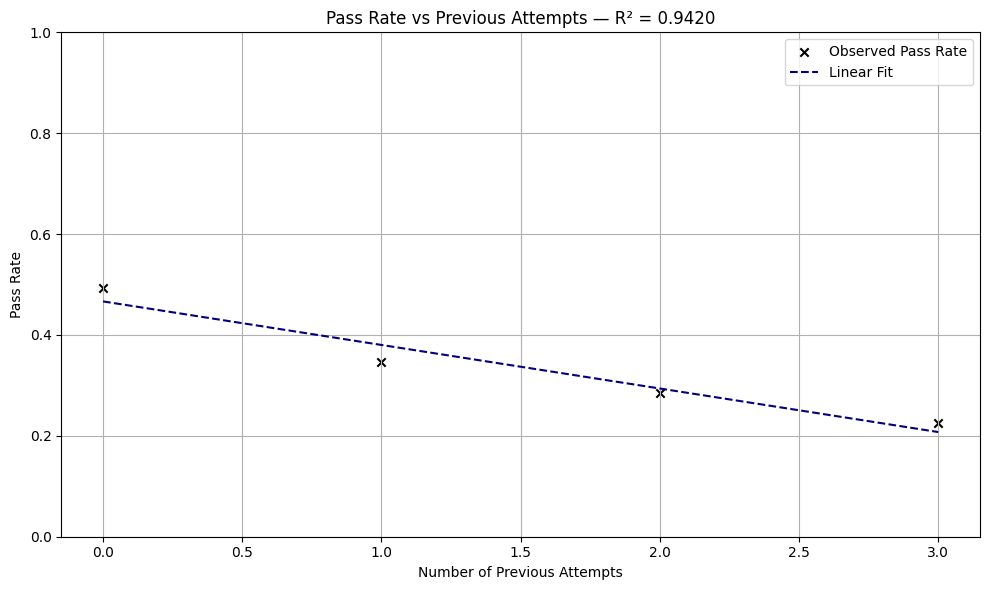

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the master table
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Create binary target (1 = Pass/Distinction, 0 = Fail/Withdrawn)
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Drop null target rows just in case
df = df.dropna(subset=['binary_target', 'num_of_prev_attempts'])

# Group by num_of_prev_attempts
grouped = df.groupby('num_of_prev_attempts')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# Optional: drop groups with very low counts (<30)
grouped = grouped[grouped['count'] >= 40]

# Regression
X = grouped[['num_of_prev_attempts']]
y = grouped['pass_rate']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', marker='x', label='Observed Pass Rate')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate vs Previous Attempts — R² = {r2:.4f}')
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/previous_attempts_r2.png', bbox_inches='tight')


plt.show()


In [54]:
df['num_of_prev_attempts'].value_counts().sort_index()


num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64

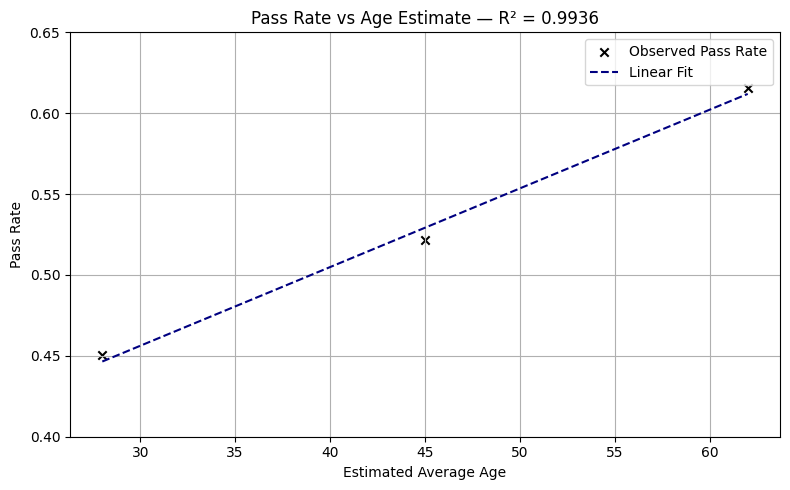

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load your data
df = pd.read_csv('/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv')

# Create binary target
df['binary_target'] = df['final_result'].map(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

# Drop rows with missing age_band or binary_target
df = df.dropna(subset=['age_band', 'binary_target'])

# Map estimated average ages
age_map = {'0-35': 28, '35-55': 45, '55<=': 62}
df['age_estimate'] = df['age_band'].map(age_map)

# Group by estimated age
grouped = df.groupby('age_estimate')['binary_target'].agg(['mean', 'count']).reset_index()
grouped.rename(columns={'mean': 'pass_rate'}, inplace=True)

# Regression
X = grouped[['age_estimate']]
y = grouped['pass_rate']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', marker='x', label='Observed Pass Rate')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')
plt.xlabel('Estimated Average Age')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate vs Age Estimate — R² = {r2:.4f}')
plt.ylim(0.4, 0.65)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/average_age_r2.png', bbox_inches='tight')

plt.show()


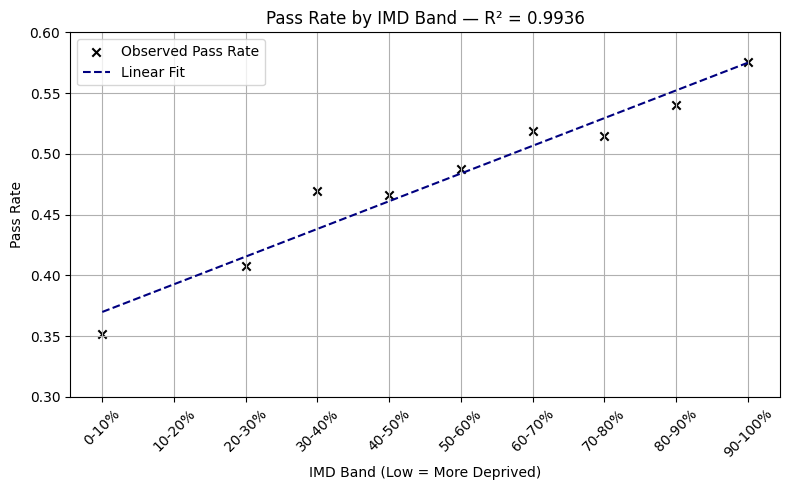

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv")

# Drop unknown IMD bands and rows with missing final_result
df_imd = df[df['imd_band'] != 'Unknown'].copy()

# Define binary target
df_imd['binary_target'] = df_imd['final_result'].isin(['Pass', 'Distinction']).astype(int)

# Map IMD bands to numeric values
imd_mapping = {
    '0-10%': 1,
    '10-20%': 2,
    '20-30%': 3,
    '30-40%': 4,
    '40-50%': 5,
    '50-60%': 6,
    '60-70%': 7,
    '70-80%': 8,
    '80-90%': 9,
    '90-100%': 10
}
df_imd['imd_numeric'] = df_imd['imd_band'].map(imd_mapping)

# Group by numeric IMD band and calculate pass rate
grouped = df_imd.groupby('imd_numeric').agg(pass_rate=('binary_target', 'mean')).reset_index()

# Create full range of bands (1–10), including missing values
all_bands = pd.DataFrame({'imd_numeric': list(range(1, 11))})
grouped_full = pd.merge(all_bands, grouped, on='imd_numeric', how='left')

# Prepare regression data (drop missing pass_rate for fitting)
regression_df = grouped_full.dropna(subset=['pass_rate'])
X = regression_df[['imd_numeric']]
y = regression_df['pass_rate']


# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Restore original IMD labels
numeric_to_label = {v: k for k, v in imd_mapping.items()}
xtick_labels = [numeric_to_label[i] for i in grouped_full['imd_numeric']]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(grouped_full['imd_numeric'], grouped_full['pass_rate'], color='black', marker='x', label='Observed Pass Rate')
plt.plot(X, y_pred, color='navy', linestyle='--', label='Linear Fit')

plt.xticks(ticks=grouped_full['imd_numeric'], labels=xtick_labels, rotation=45)
plt.xlabel('IMD Band (Low = More Deprived)')
plt.ylabel('Pass Rate')
plt.title(f'Pass Rate by IMD Band — R² = {r2:.4f}')
plt.ylim(0.3, 0.6)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('/Users/jamesjackson/Documents/student_outcome_analysis/data/visualisations/final_r2/IMD_band_r2.png', bbox_inches='tight')


plt.show()

# Print R²
r2 = r2_score(y, model.predict(X))


In [109]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv")

# Create binary target
df['binary_target'] = df['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

# Drop rows with missing values
df_gender = df[['gender', 'binary_target']].dropna()

# Step 1: Get average pass rate per gender
gender_pass_rates = df_gender.groupby('gender')['binary_target'].mean()

# Step 2: Map predicted values
df_gender['predicted_pass_rate'] = df_gender['gender'].map(gender_pass_rates)

# Step 3: Regression
X = df_gender[['predicted_pass_rate']]
y = df_gender['binary_target']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"R² for gender: {r2:.4f}")


df.to_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table-with-target.csv", index=False)

R² for gender: 0.0005


In [112]:
import pandas as pd
from sklearn.metrics import r2_score
import numpy as np

# Load data
df = pd.read_csv("/Users/jamesjackson/Documents/student_outcome_analysis/data/master-table.csv")

# Drop rows with missing final_result or disability
df = df[['disability', 'final_result']].dropna()

# Create binary target
df['binary_target'] = df['final_result'].isin(['Pass', 'Distinction']).astype(int)

# Step 1: Calculate mean pass rate for each group
group_means = df.groupby('disability')['binary_target'].transform('mean')

# Step 2: Calculate overall mean
overall_mean = df['binary_target'].mean()

# Step 3: R² as explained variance
ss_between = ((group_means - overall_mean) ** 2).sum()
ss_total = ((df['binary_target'] - overall_mean) ** 2).sum()
r2 = ss_between / ss_total

print(f"R² for Disability: {r2:.4f}")


R² for Disability: 0.0035
